# Region Trolley Response Scales


In [6]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# seaborn triggers a matplotlib 3.11 internal PendingDeprecationWarning — not actionable here
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

DATA_PATH   = Path("../data/raw data/weekly_by_region_202604082051.csv")

_pop = (
    pd.read_csv("../supplementary data/2022_hr_population.csv")
    .rename(columns={"HSE Health Regions": "Region", "Number of persons": "Population"})
    .drop_duplicates(subset="Region")
    .sort_values("Population", ascending=False)
)

# Ordered by population descending (2022); no HSE prefix — matches supplementary data
REGION_ORDER = _pop["Region"].tolist()
STD_BAR_FIG_SIZE = (10, 4)

REGION_COLOR = {
    "Dublin and North East": "#1f77b4",
    "Dublin and Midlands":   "#ff7f0e",
    "Dublin and South East": "#2ca02c",
    "West and North West":   "#d62728",
    "South West":            "#9467bd",
    "Mid West":              "#8c564b",
}

# Snapshot date for the Excel export — set to None to use latest in dataset
SNAPSHOT_DATE = None   # e.g. "31/12/2024"

## Load & clean data

In [7]:
df = pd.read_csv(DATA_PATH)
df["week_start"] = pd.to_datetime(df["week_start"])

print(f"Rows: {len(df):,}  |  Date range: {df['week_start'].min().date()} – {df['week_start'].max().date()}")
print(f"Regions: {df['region'].nunique()}  |  Weeks: {df['week_start'].nunique()}")
print(f"Missing total_trolleys: {df['total_trolleys'].isna().sum():,} rows ({df['total_trolleys'].isna().mean():.1%})")

Rows: 1,032  |  Date range: 2022-12-26 – 2026-04-06
Regions: 6  |  Weeks: 172
Missing total_trolleys: 0 rows (0.0%)


## Weekly regional totals

In [8]:
# Data is already aggregated to weekly level; drop partial weeks at boundaries
full_weeks = df[df["days_in_week"] == 7].copy()

print(f"Complete weeks: {full_weeks['week_start'].nunique()}")
full_weeks.groupby("region")["total_trolleys"].describe().round(1)

Complete weeks: 170


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
HSE Dublin and Midlands,170.0,411.7,148.2,33.0,296.0,408.5,497.0,819.0
HSE Dublin and North East,170.0,259.5,100.9,21.0,195.8,258.0,327.0,588.0
HSE Dublin and South East,170.0,286.8,90.0,88.0,217.8,279.5,348.5,584.0
HSE Mid West,170.0,328.8,89.5,0.0,301.2,349.5,387.0,501.0
HSE South West,170.0,334.7,116.6,106.0,241.5,337.0,416.0,683.0
HSE West and North West,170.0,486.0,118.2,111.0,412.2,474.0,563.5,800.0


## Cross-correlations between regions (raw weekly totals)

Each off-diagonal panel shows the cross-correlation function (CCF) between the row region's series and the column region's series across lags of ±26 weeks. Diagonals are auto-correlations. Dashed red lines are approximate 95% white-noise bounds (±1.96/√N).

Caveat: computed on raw counts, which share a common annual cycle and a trend — cross-correlations near lag 0 will be inflated by these shared components rather than reflecting region-specific lead/lag structure. Differencing or de-cycling first would isolate that.

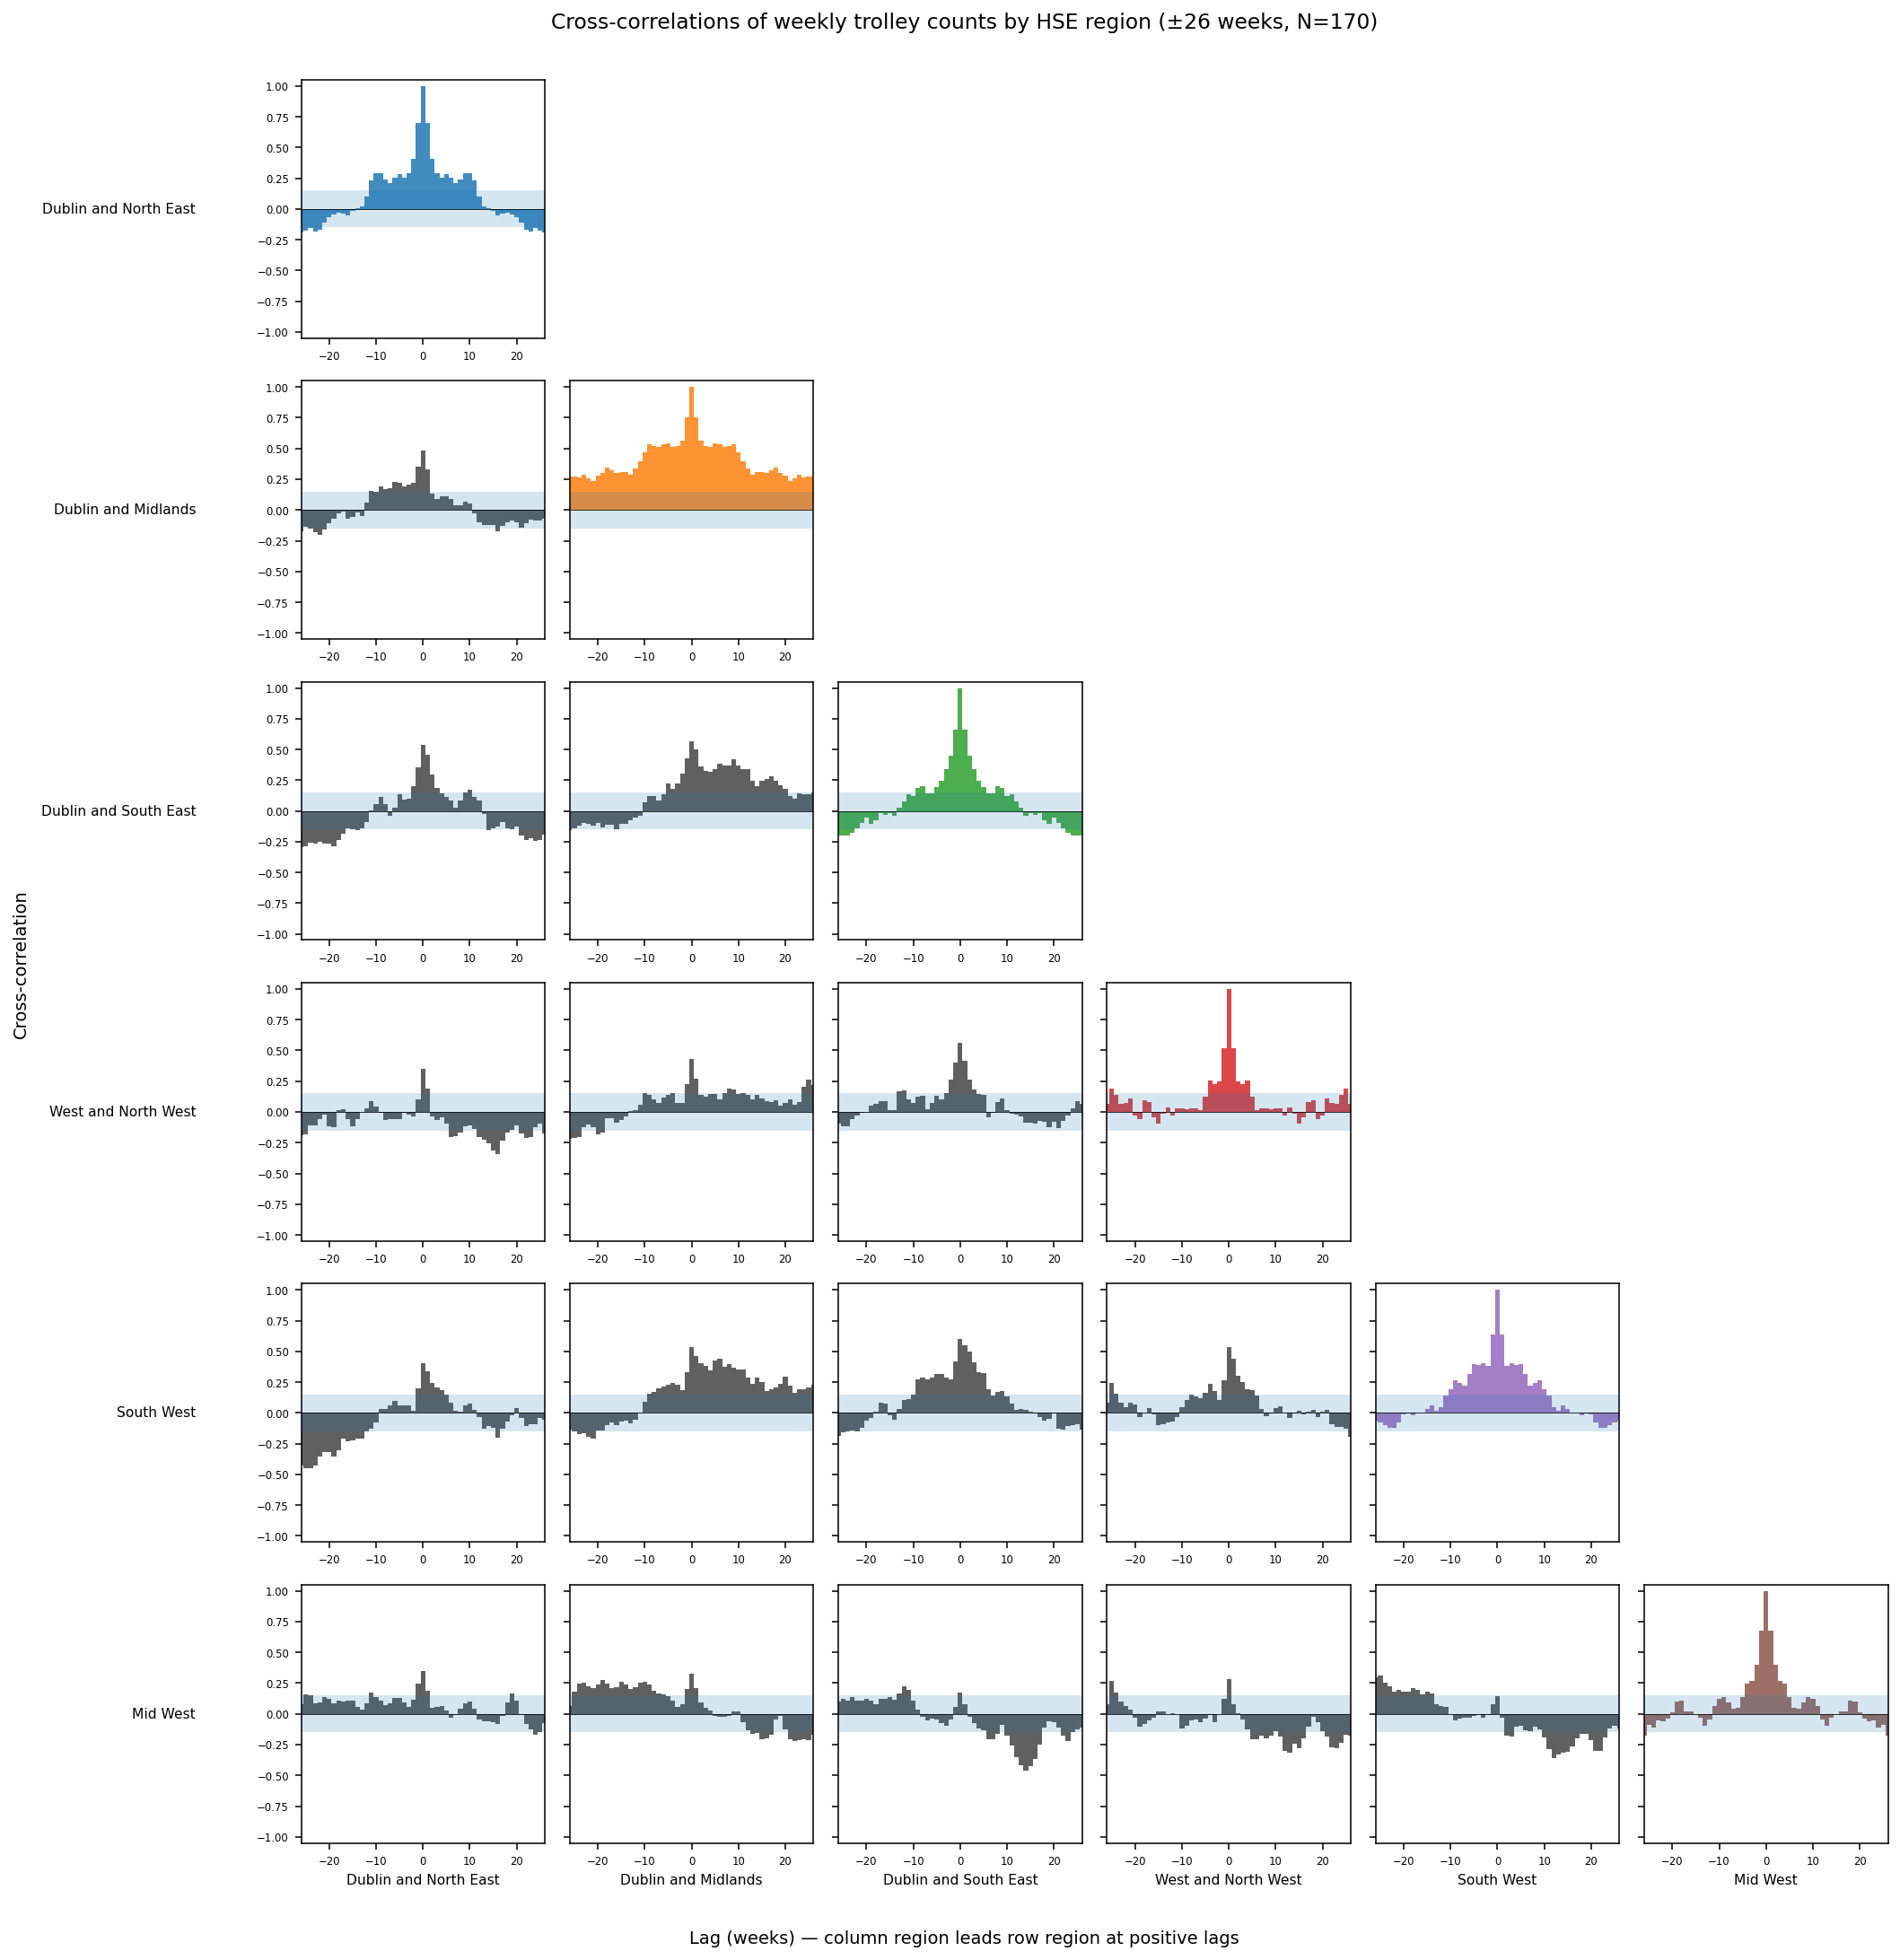

In [9]:
import numpy as np

MAX_LAG = 26  # weeks (~6 months)

# Wide: rows = weeks, cols = regions; ordered by 2022 population (desc)
ordered_cols = ["HSE " + r for r in REGION_ORDER]
wide = (
    full_weeks.pivot(index="week_start", columns="region", values="total_trolleys")
    .sort_index()[ordered_cols]
)
labels = [c.replace("HSE ", "") for c in wide.columns]
N = len(wide)
ci = 1.96 / np.sqrt(N)


def ccf(x, y, max_lag):
    """CCF[k] = corr(x_t, y_{t+k}) for k in [-max_lag, +max_lag]."""
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    lags = np.arange(-max_lag, max_lag + 1)
    out = np.empty_like(lags, dtype=float)
    for i, k in enumerate(lags):
        if k >= 0:
            xs, ys = x[: N - k], y[k:]
        else:
            xs, ys = x[-k:], y[: N + k]
        out[i] = np.corrcoef(xs, ys)[0, 1]
    return lags, out


n = len(wide.columns)
fig, axes = plt.subplots(n, n, figsize=(15, 15), dpi=140, sharex=True, sharey=True)

for i, col_i in enumerate(wide.columns):
    for j, col_j in enumerate(wide.columns):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
            continue
        lags, r = ccf(wide[col_i].values, wide[col_j].values, MAX_LAG)
        color = REGION_COLOR[labels[i]] if i == j else "#444444"
        ax.bar(lags, r, width=1.0, color=color, alpha=0.85, linewidth=0)
        ax.axhline(0, color="black", linewidth=0.4)
        ax.axhspan(-ci, ci, color="#1f77b4", alpha=0.18, linewidth=0)
        ax.set_ylim(-1.05, 1.05)
        ax.set_xlim(-MAX_LAG, MAX_LAG)
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=8, rotation=0, ha="right", va="center", labelpad=35)
        if i == n - 1:
            ax.set_xlabel(labels[j], fontsize=8)
        ax.tick_params(axis="x", labelsize=6, labelbottom=True)
        ax.tick_params(axis="y", labelsize=6)

# Shared axis labels
fig.text(0.5, -0.02, "Lag (weeks) — column region leads row region at positive lags", ha="center", fontsize=10)
fig.text(-0.005, 0.5, "Cross-correlation", va="center", rotation="vertical", fontsize=10)

plt.suptitle(
    f"Cross-correlations of weekly trolley counts by HSE region "
    f"(±{MAX_LAG} weeks, N={N})",
    fontsize=12, y=1.005,
)
plt.tight_layout()
plt.show()

## Box plots — weekly total trolley counts by region

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/11216303.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")


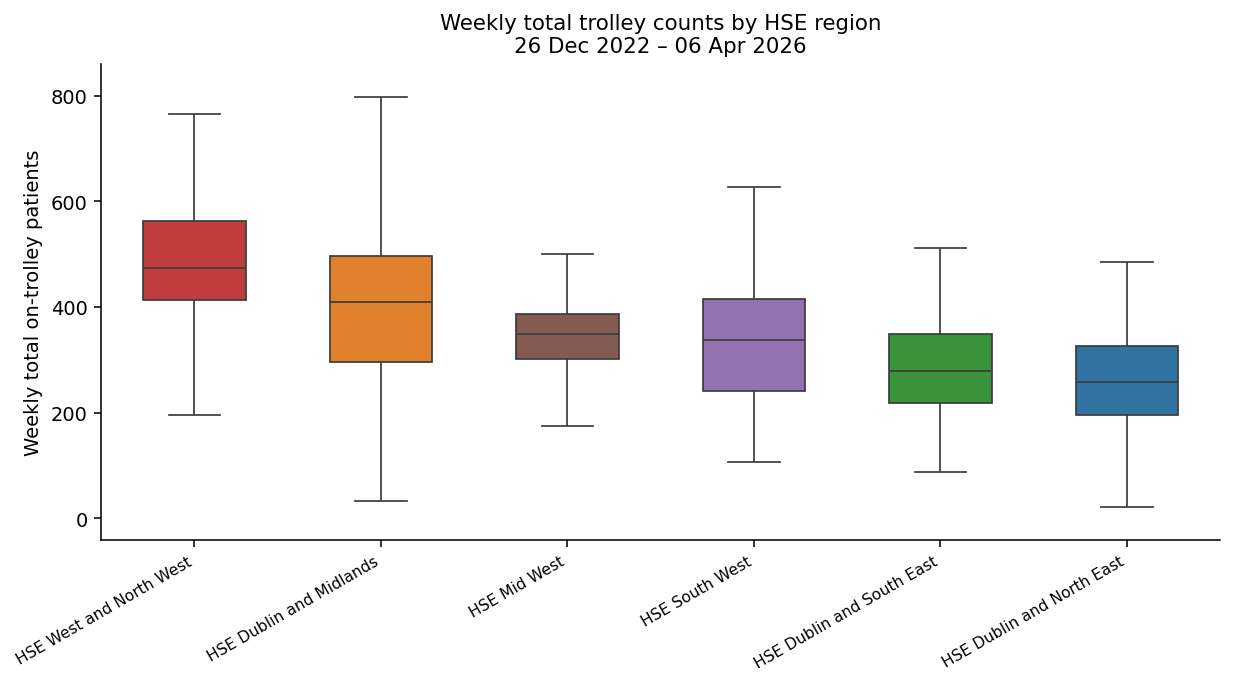

In [10]:
# Main trolley data has "HSE " prefix — build palette accordingly
PALETTE = {"HSE " + k: v for k, v in REGION_COLOR.items()}

fig, ax = plt.subplots(figsize=(9, 5), dpi=140)
order = full_weeks.groupby("region")["total_trolleys"].describe().round(1).sort_values("50%", ascending=False).index.to_list()

sns.boxplot(
    data=full_weeks,
    x="region",
    y="total_trolleys",
    hue="region",
    order=order,
    palette=PALETTE,
    legend=False,
    width=0.55,
    linewidth=0.9,
    flierprops=dict(marker="o", markersize=2.5, alpha=0.4, markeredgewidth=0),
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Weekly total on-trolley patients", fontsize=10)
ax.set_title(
    f"Weekly total trolley counts by HSE region\n"
    f"{df['week_start'].min().strftime('%d %b %Y')} – {df['week_start'].max().strftime('%d %b %Y')}",
    fontsize=11,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", labelsize=8, rotation=30)
ax.set_xticklabels(ax.get_xticklabels(), ha="right")
sns.despine()
plt.tight_layout()

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2279241634.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2279241634.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2279241634.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2279241634.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

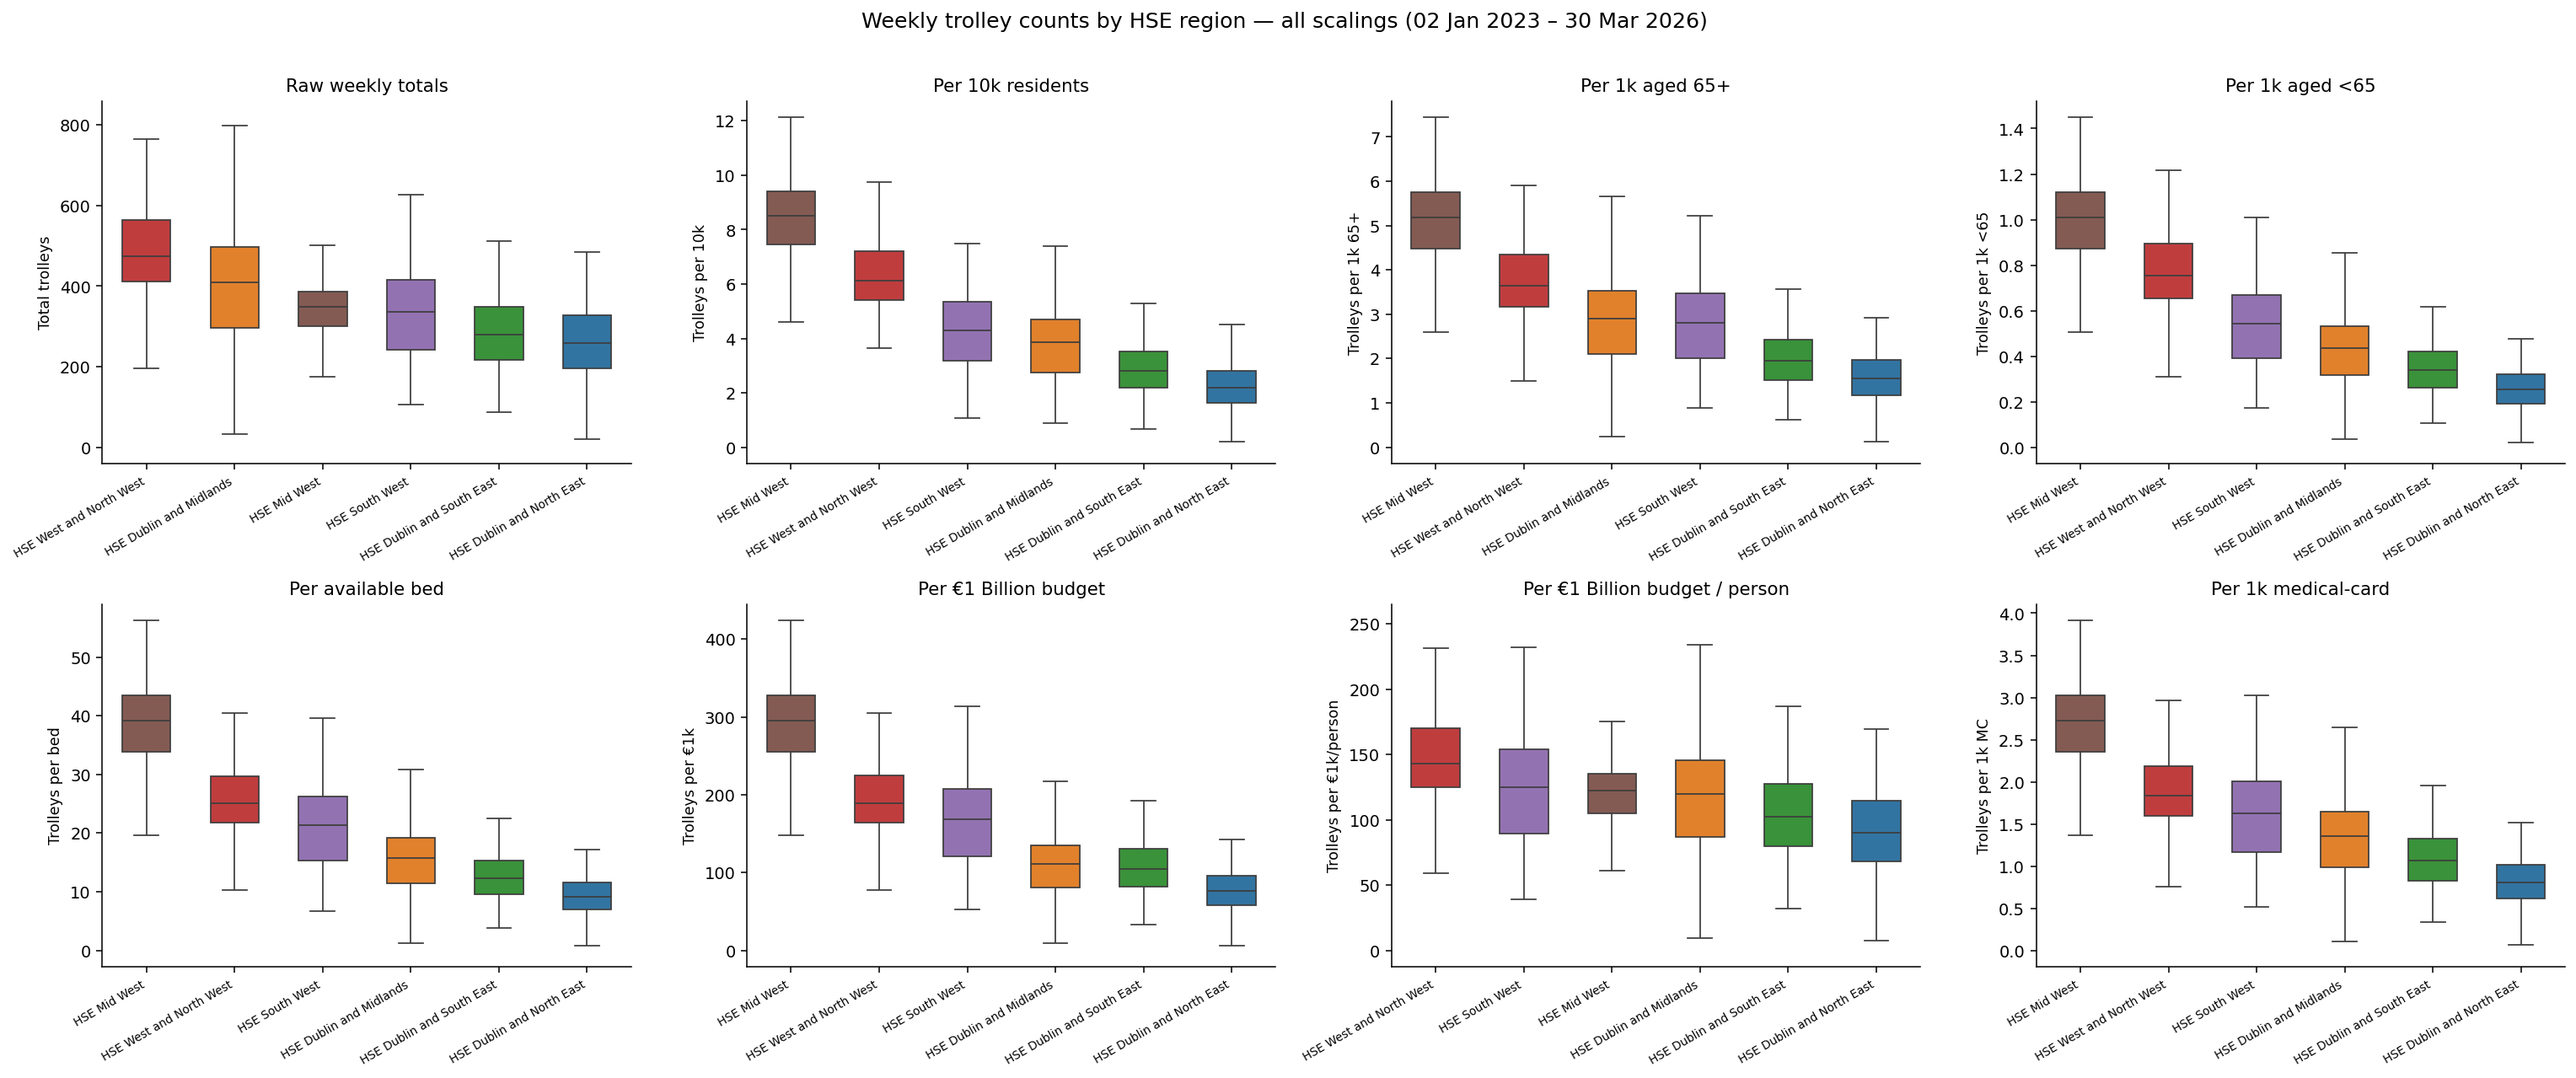

In [11]:
SCALINGS = [
    ("raw",                                                "Raw weekly totals",        "Total trolleys"),
    ("../data/wide_weekly_scaledPer10k.csv",               "Per 10k residents",        "Trolleys per 10k"),
    ("../data/wide_weekly_scaledPer1kOver65.csv",          "Per 1k aged 65+",          "Trolleys per 1k 65+"),
    ("../data/wide_weekly_scaledPer1kUnder65.csv",         "Per 1k aged <65",          "Trolleys per 1k <65"),
    ("../data/wide_weekly_scaledPerBed.csv",               "Per available bed",        "Trolleys per bed"),
    ("../data/wide_weekly_scaledPerBudgetThousands.csv",   "Per €1 Billion budget",           "Trolleys per €1k"),
    ("../data/wide_weekly_scaledPerBudgetPerPerson.csv",   "Per €1 Billion budget / person",  "Trolleys per €1k/person"),
    ("../data/wide_weekly_scaledPer1kMedicalCard.csv",     "Per 1k medical-card",      "Trolleys per 1k MC"),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 9), dpi=140)
axes = axes.flatten()

for ax, (path, title, ylabel) in zip(axes, SCALINGS):
    if path == "raw":
        long = full_weeks.rename(columns={"region": "Region", "total_trolleys": "value"})[
            ["Region", "week_start", "value"]
        ]
    else:
        long = (
            pd.read_csv(path)
            .melt(id_vars="Region", var_name="week_start", value_name="value")
        )
        long["week_start"] = pd.to_datetime(long["week_start"])

    order = (
        long.groupby("Region")["value"]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    sns.boxplot(
        data=long,
        x="Region",
        y="value",
        hue="Region",
        order=order,
        palette=PALETTE,
        legend=False,
        width=0.55,
        linewidth=0.9,
        flierprops=dict(marker="o", markersize=2.5, alpha=0.4, markeredgewidth=0),
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right")
    sns.despine(ax=ax)

for ax in axes[len(SCALINGS):]:
    ax.set_visible(False)

date_min = long["week_start"].min().strftime('%d %b %Y')
date_max = long["week_start"].max().strftime('%d %b %Y')
plt.suptitle(f"Weekly trolley counts by HSE region — all scalings ({date_min} – {date_max})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
CATCHMENT_PATH = Path("../supplementary data/2022_hr_population.csv")

catch = (
    pd.read_csv(CATCHMENT_PATH)
    .rename(columns={"HSE Health Regions": "Region", "Number of persons": "Population"})
    .drop_duplicates(subset="Region")
)

catch = catch.sort_values("Population").reset_index(drop=True)
catch["Population_k"] = catch["Population"] / 1_000

## Health region population

In [13]:
BEDS_PATH = Path("../supplementary data/2025_hr_beds_per_hospital.csv")

beds = pd.read_csv(BEDS_PATH)

beds_by_region = (
    beds.groupby("region", as_index=False)
    .agg(
        total_inpatient=("tx_inpatient",       "sum"),
        closed_inpatient=("closures_inpatient", "sum"),
    )
)
beds_by_region["available_inpatient"] = (
    beds_by_region["total_inpatient"] - beds_by_region["closed_inpatient"]
)
beds_by_region = beds_by_region.sort_values("available_inpatient").reset_index(drop=True)

## 2026 budget per region

In [14]:
BUDGET_PATH = Path("../supplementary data/2026_hr_budget.xlsx")

budget = (
    pd.read_excel(BUDGET_PATH)
    .melt(var_name="Region", value_name="Budget")
)
budget["Budget_m"] = budget["Budget"] / 1_000
budget["Region"] = budget["Region"].str.replace("HSE ", "", regex=False)
budget["Region"] = pd.Categorical(budget["Region"], categories=REGION_ORDER, ordered=True)
budget = budget.sort_values("Budget_m").reset_index(drop=True)

## Age distribution by region

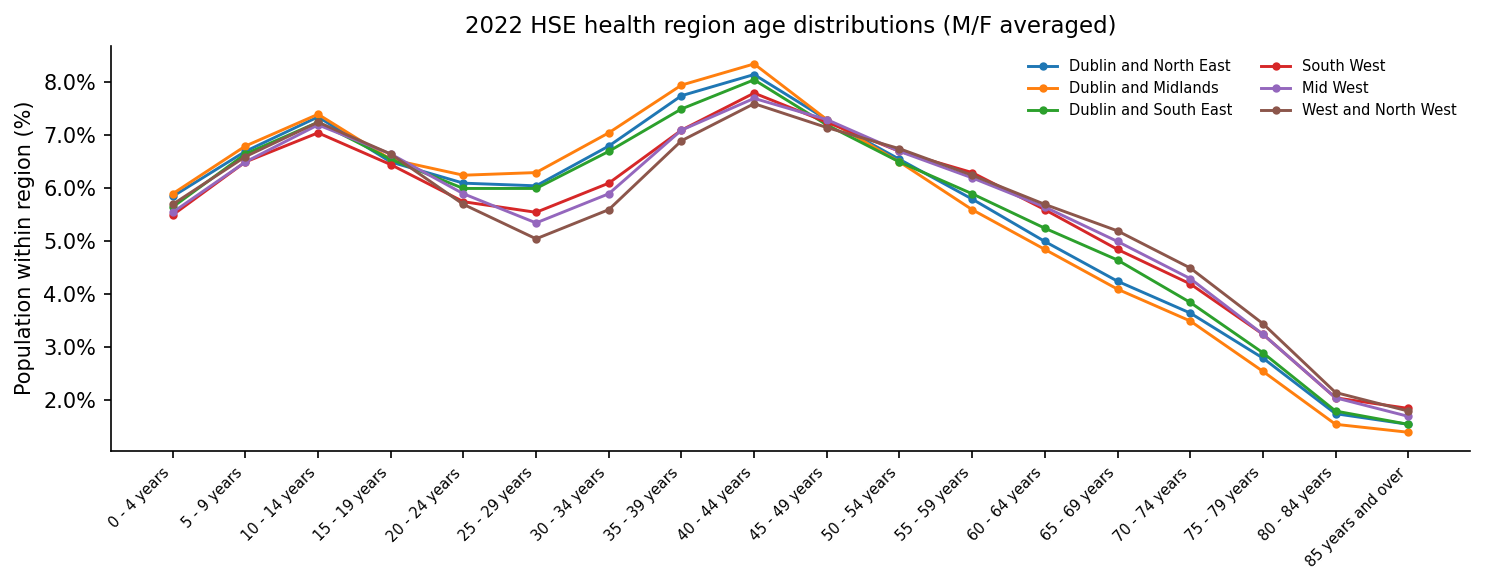

In [15]:
AGE_PATH = Path("../supplementary data/2022_hr_age_dist.csv")

age_raw = pd.read_csv(AGE_PATH)
age_raw = age_raw[age_raw["Age Group"] != "All ages"]

# Preserve order as it appears in the file
AGE_GROUP_ORDER = age_raw["Age Group"].unique().tolist()
CSV_REGIONS     = age_raw["HSE Regions"].unique().tolist()

# Average Male and Female % per region/age group
age_avg = (
    age_raw.groupby(["HSE Regions", "Age Group"])["VALUE"]
    .mean()
    .reset_index()
)
age_avg["Age Group"] = pd.Categorical(age_avg["Age Group"], categories=AGE_GROUP_ORDER, ordered=True)
age_avg = age_avg.sort_values(["HSE Regions", "Age Group"])

# --- Plot: overlapping line distributions ---
LINE_PALETTE = sns.color_palette("tab10", n_colors=len(CSV_REGIONS))

fig, ax = plt.subplots(figsize=STD_BAR_FIG_SIZE, dpi=150)

for i, region in enumerate(CSV_REGIONS):
    subset = age_avg[age_avg["HSE Regions"] == region]
    ax.plot(range(len(AGE_GROUP_ORDER)), subset["VALUE"].values,
            marker="o", markersize=3, linewidth=1.4,
            color=LINE_PALETTE[i], label=region)

ax.set_xticks(range(len(AGE_GROUP_ORDER)))
ax.set_xticklabels(AGE_GROUP_ORDER, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Population within region (%)", fontsize=10)
ax.set_title("2022 HSE health region age distributions (M/F averaged)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend(fontsize=7, frameon=False, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()

# --- Data prep: % aged 65+ per region (used in combined bar subplot) ---
age_avg["is_65plus"] = age_avg["Age Group"].isin([
    "65 - 69 years", "70 - 74 years", "75 - 79 years",
    "80 - 84 years", "85 years and over",
])
pct_60plus = (
    age_avg[age_avg["is_65plus"]]
    .groupby("HSE Regions")["VALUE"]
    .sum()
    .reset_index()
    .rename(columns={"VALUE": "Pct_60plus"})
)
pct_60plus = pct_60plus.sort_values("Pct_60plus").reset_index(drop=True)

## Medical card (GP visit card) coverage by region

In [16]:
mc = pd.read_csv("../supplementary data/2022_hr_medical_card_perc.csv")
mc = mc.rename(columns={"HSE Health Regions": "Region", "VALUE": "Pct"})
mc = mc.sort_values("Pct").reset_index(drop=True)

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

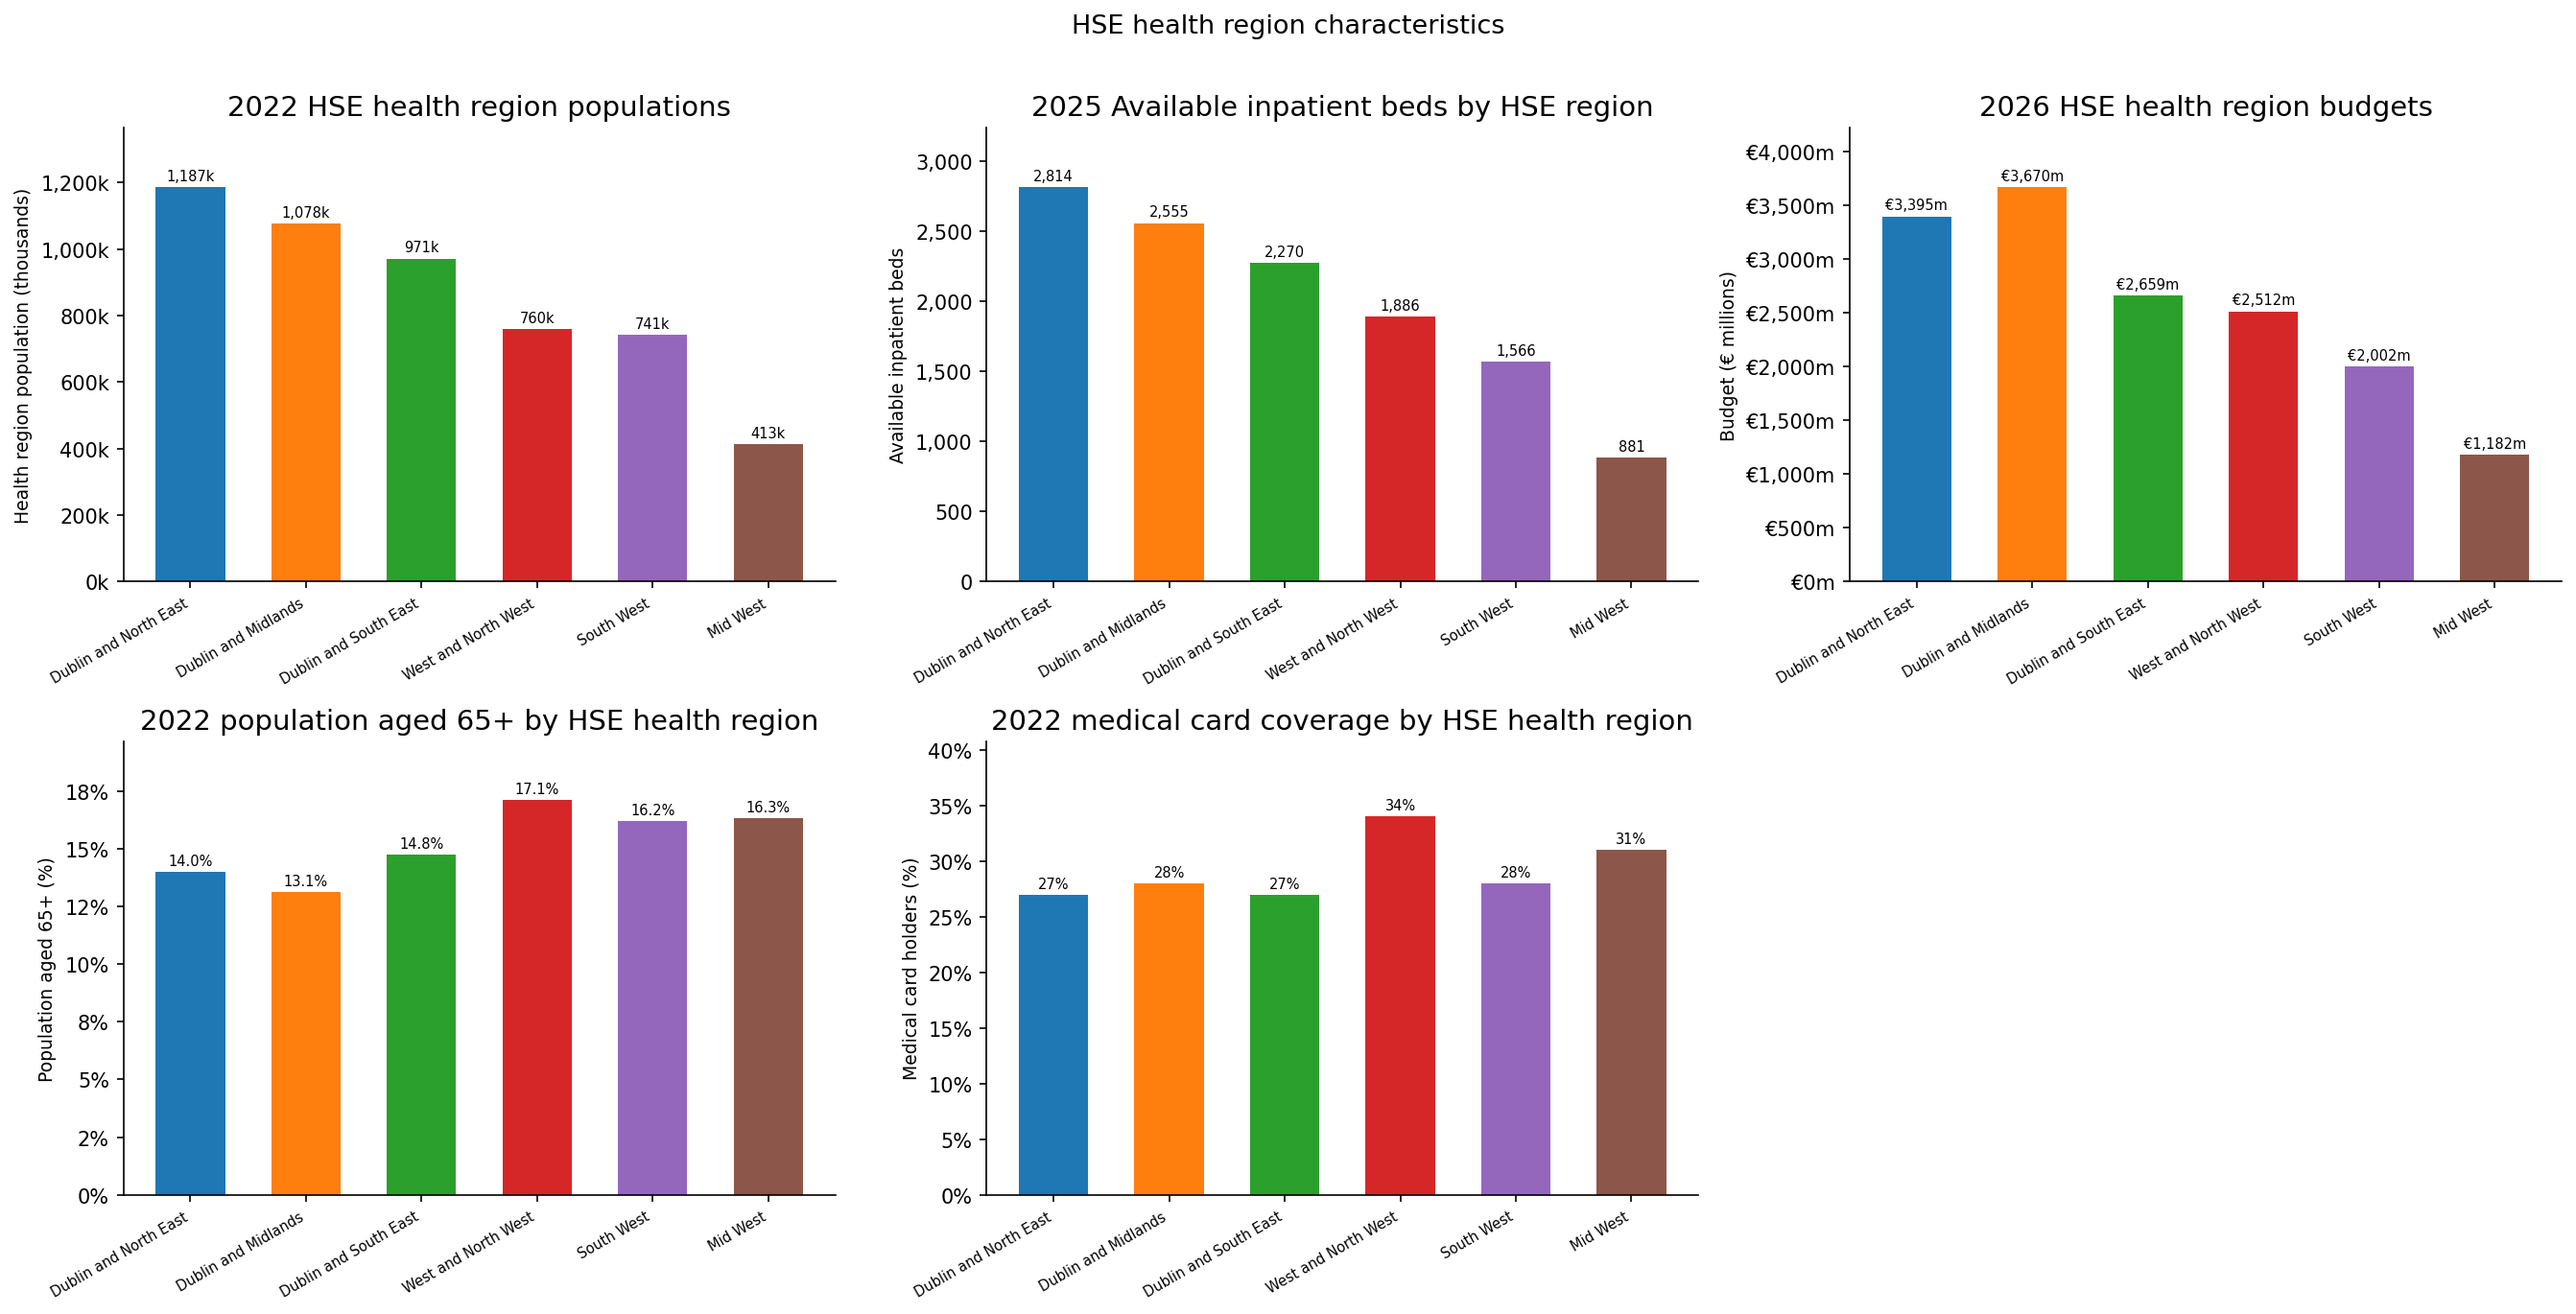

In [17]:
def _bar_with_labels(ax, x, y, fmt, ylabel, title, colors=None, ylim_factor=1.15):
    pad = max(y) * 0.01
    bars = ax.bar(x, y, color=colors, linewidth=0.1, width=0.6)
    for bar, val in zip(bars, y):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + pad,
            fmt(val),
            ha="center", va="bottom", fontsize=7,
        )
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=14)
    ax.set_ylim(0, max(y) * ylim_factor)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right")
    sns.despine(ax=ax)

# Ordered by population descending
pop_order = catch.sort_values("Population_k", ascending=False)["Region"].tolist()
bar_colors = [REGION_COLOR[r] for r in pop_order]

def align(df, region_col, val_col):
    return df.set_index(region_col)[val_col].reindex(pop_order).values

pop_vals    = align(catch,           "Region",      "Population_k")
beds_vals   = align(beds_by_region, "region",      "available_inpatient")
budget_vals = align(budget,         "Region",      "Budget_m")
age_vals    = align(pct_60plus,     "HSE Regions", "Pct_60plus")
mc_vals     = align(mc,             "Region",      "Pct")

fig, axes = plt.subplots(2, 3, figsize=(18, 9), dpi=150)
axes = axes.flatten()

_bar_with_labels(
    axes[0], pop_order, pop_vals,
    fmt=lambda v: f"{v:,.0f}k",
    ylabel="Health region population (thousands)",
    title="2022 HSE health region populations",
    colors=bar_colors,
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}k"))

_bar_with_labels(
    axes[1], pop_order, beds_vals,
    fmt=lambda v: f"{int(v):,}",
    ylabel="Available inpatient beds",
    title="2025 Available inpatient beds by HSE region",
    colors=bar_colors,
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

_bar_with_labels(
    axes[2], pop_order, budget_vals,
    fmt=lambda v: f"€{v:,.0f}m",
    ylabel="Budget (€ millions)",
    title="2026 HSE health region budgets",
    colors=bar_colors,
)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{int(x):,}m"))

_bar_with_labels(
    axes[3], pop_order, age_vals,
    fmt=lambda v: f"{v:.1f}%",
    ylabel="Population aged 65+ (%)",
    title="2022 population aged 65+ by HSE health region",
    colors=bar_colors,
)
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

_bar_with_labels(
    axes[4], pop_order, mc_vals,
    fmt=lambda v: f"{v}%",
    ylabel="Medical card holders (%)",
    title="2022 medical card coverage by HSE health region",
    colors=bar_colors,
    ylim_factor=1.2,
)
axes[4].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}%"))

axes[5].set_visible(False)

plt.suptitle("HSE health region characteristics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

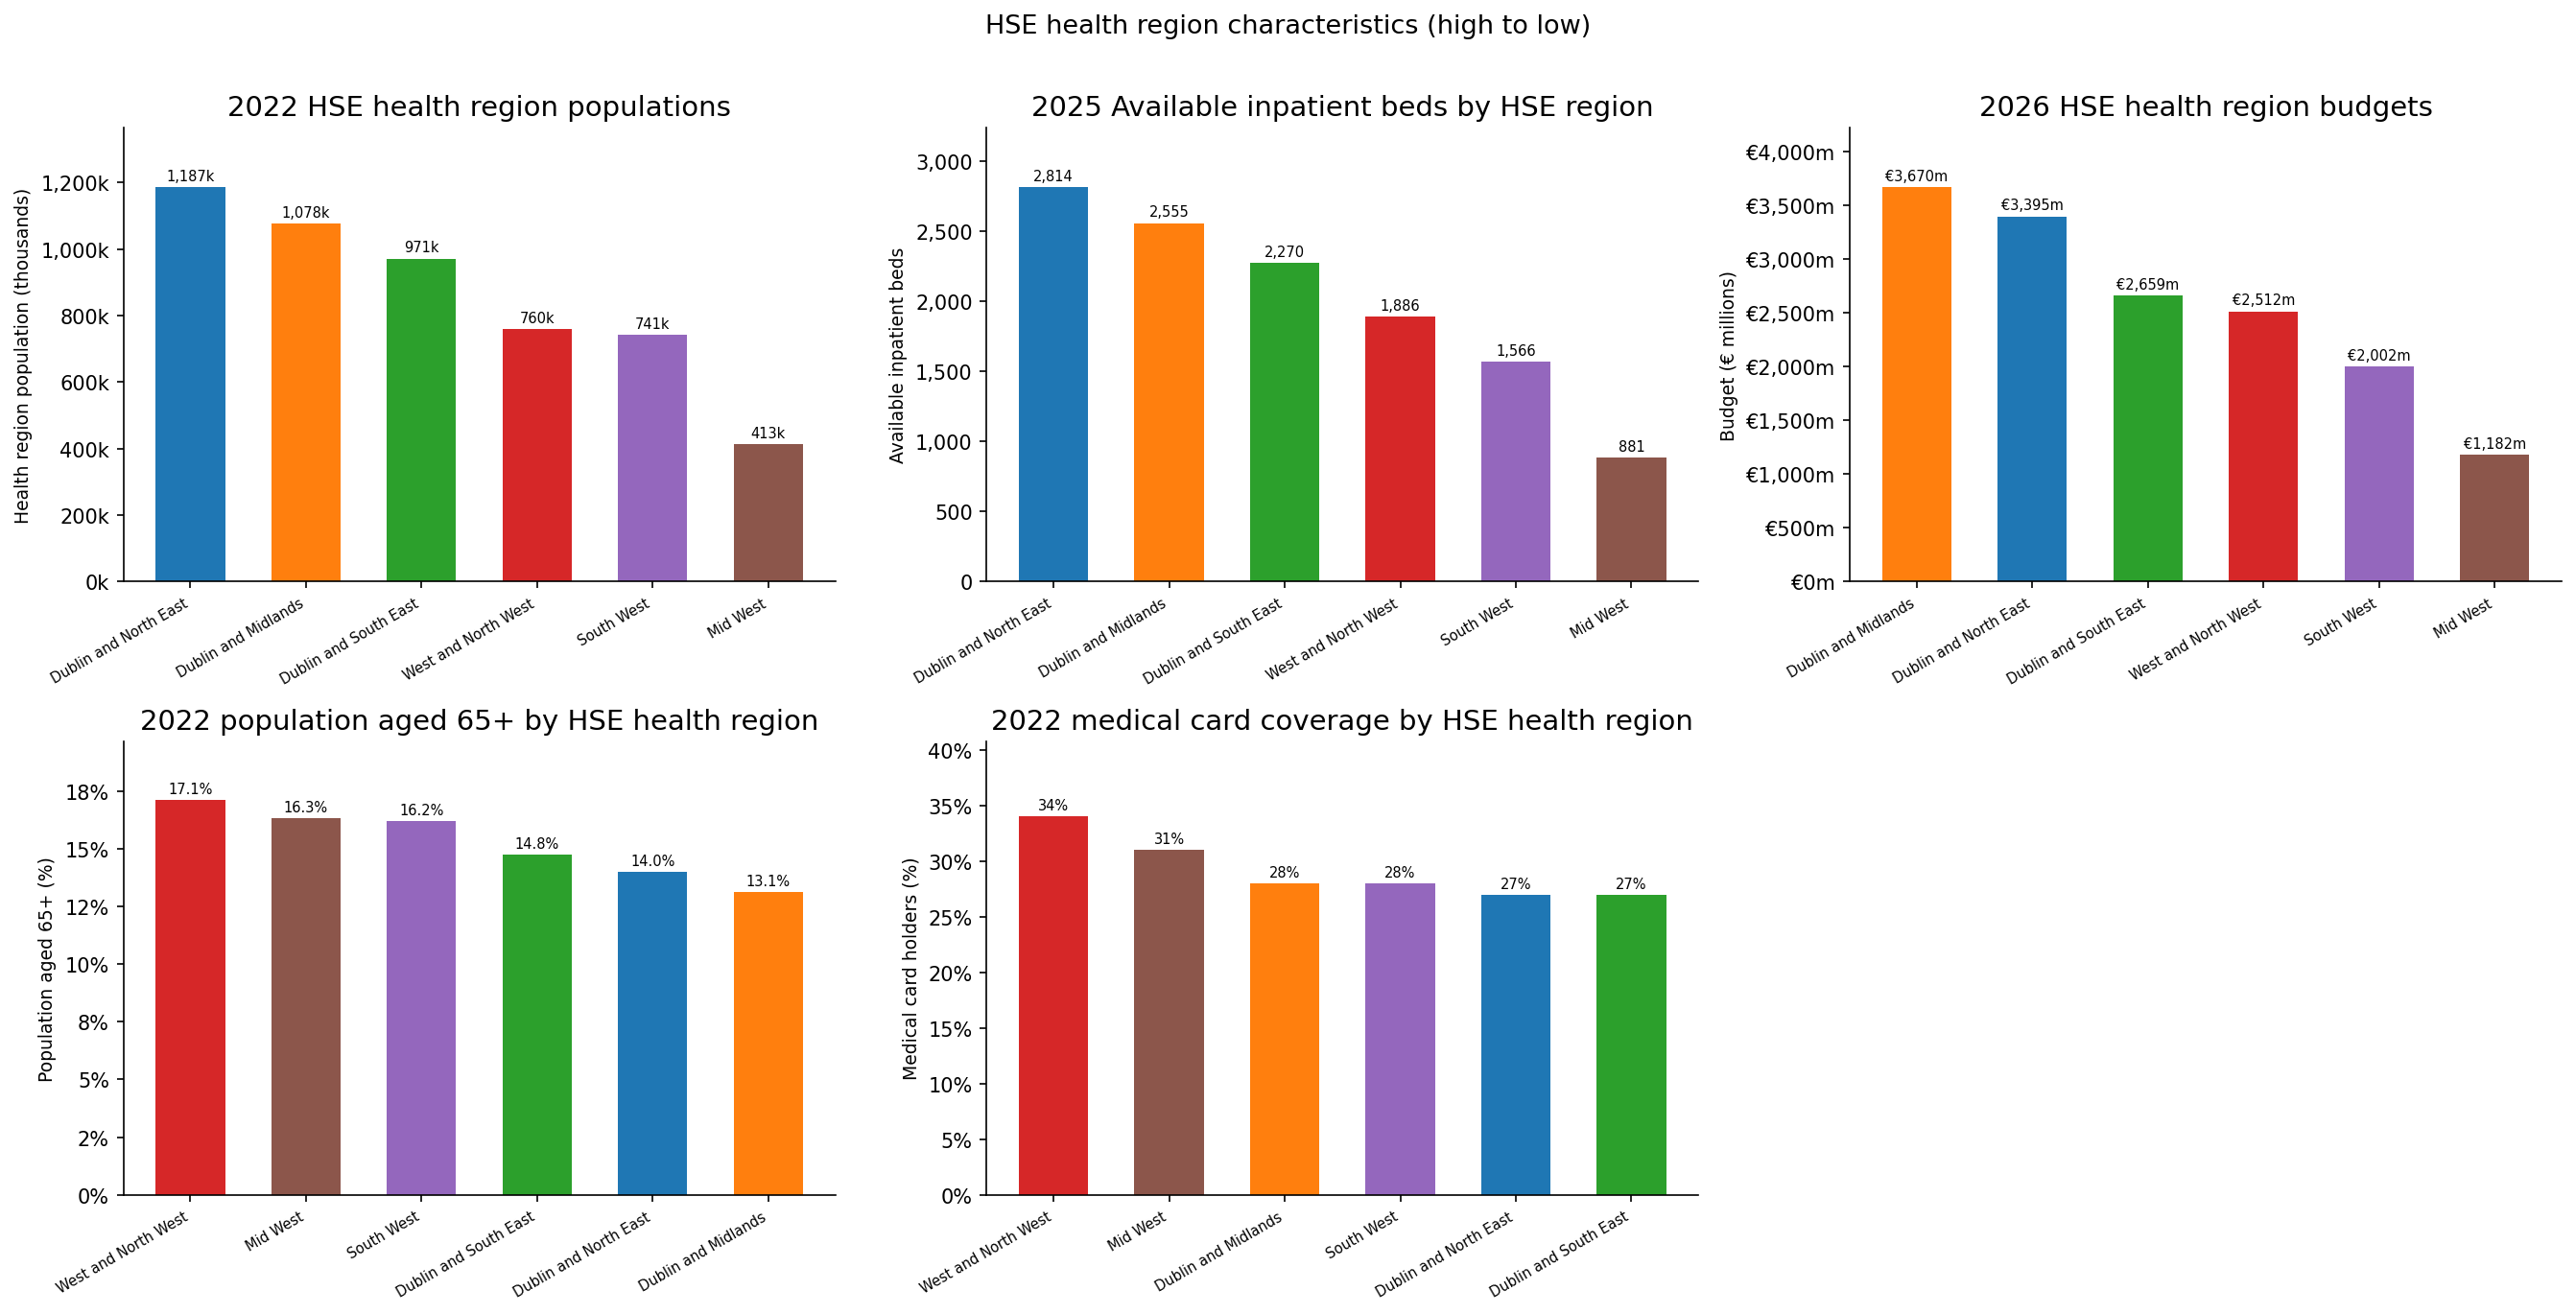

In [18]:
def _sort_desc(regions, values):
    pairs = sorted(zip(regions, values), key=lambda p: p[1], reverse=True)
    x = [p[0] for p in pairs]
    y = [p[1] for p in pairs]
    colors = [REGION_COLOR[r] for r in x]
    return x, y, colors

fig, axes = plt.subplots(2, 3, figsize=(18, 9), dpi=150)
axes = axes.flatten()

x, y, c = _sort_desc(catch["Region"].tolist(), catch["Population_k"].tolist())
_bar_with_labels(axes[0], x, y, fmt=lambda v: f"{v:,.0f}k",
    ylabel="Health region population (thousands)", title="2022 HSE health region populations", colors=c)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}k"))

x, y, c = _sort_desc(beds_by_region["region"].tolist(), beds_by_region["available_inpatient"].tolist())
_bar_with_labels(axes[1], x, y, fmt=lambda v: f"{int(v):,}",
    ylabel="Available inpatient beds", title="2025 Available inpatient beds by HSE region", colors=c)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

x, y, c = _sort_desc(budget["Region"].tolist(), budget["Budget_m"].tolist())
_bar_with_labels(axes[2], x, y, fmt=lambda v: f"€{v:,.0f}m",
    ylabel="Budget (€ millions)", title="2026 HSE health region budgets", colors=c)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{int(x):,}m"))

x, y, c = _sort_desc(pct_60plus["HSE Regions"].tolist(), pct_60plus["Pct_60plus"].tolist())
_bar_with_labels(axes[3], x, y, fmt=lambda v: f"{v:.1f}%",
    ylabel="Population aged 65+ (%)", title="2022 population aged 65+ by HSE health region", colors=c)
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

x, y, c = _sort_desc(mc["Region"].tolist(), mc["Pct"].tolist())
_bar_with_labels(axes[4], x, y, fmt=lambda v: f"{v}%",
    ylabel="Medical card holders (%)", title="2022 medical card coverage by HSE health region",
    colors=c, ylim_factor=1.2)
axes[4].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}%"))

axes[5].set_visible(False)

plt.suptitle("HSE health region characteristics (high to low)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

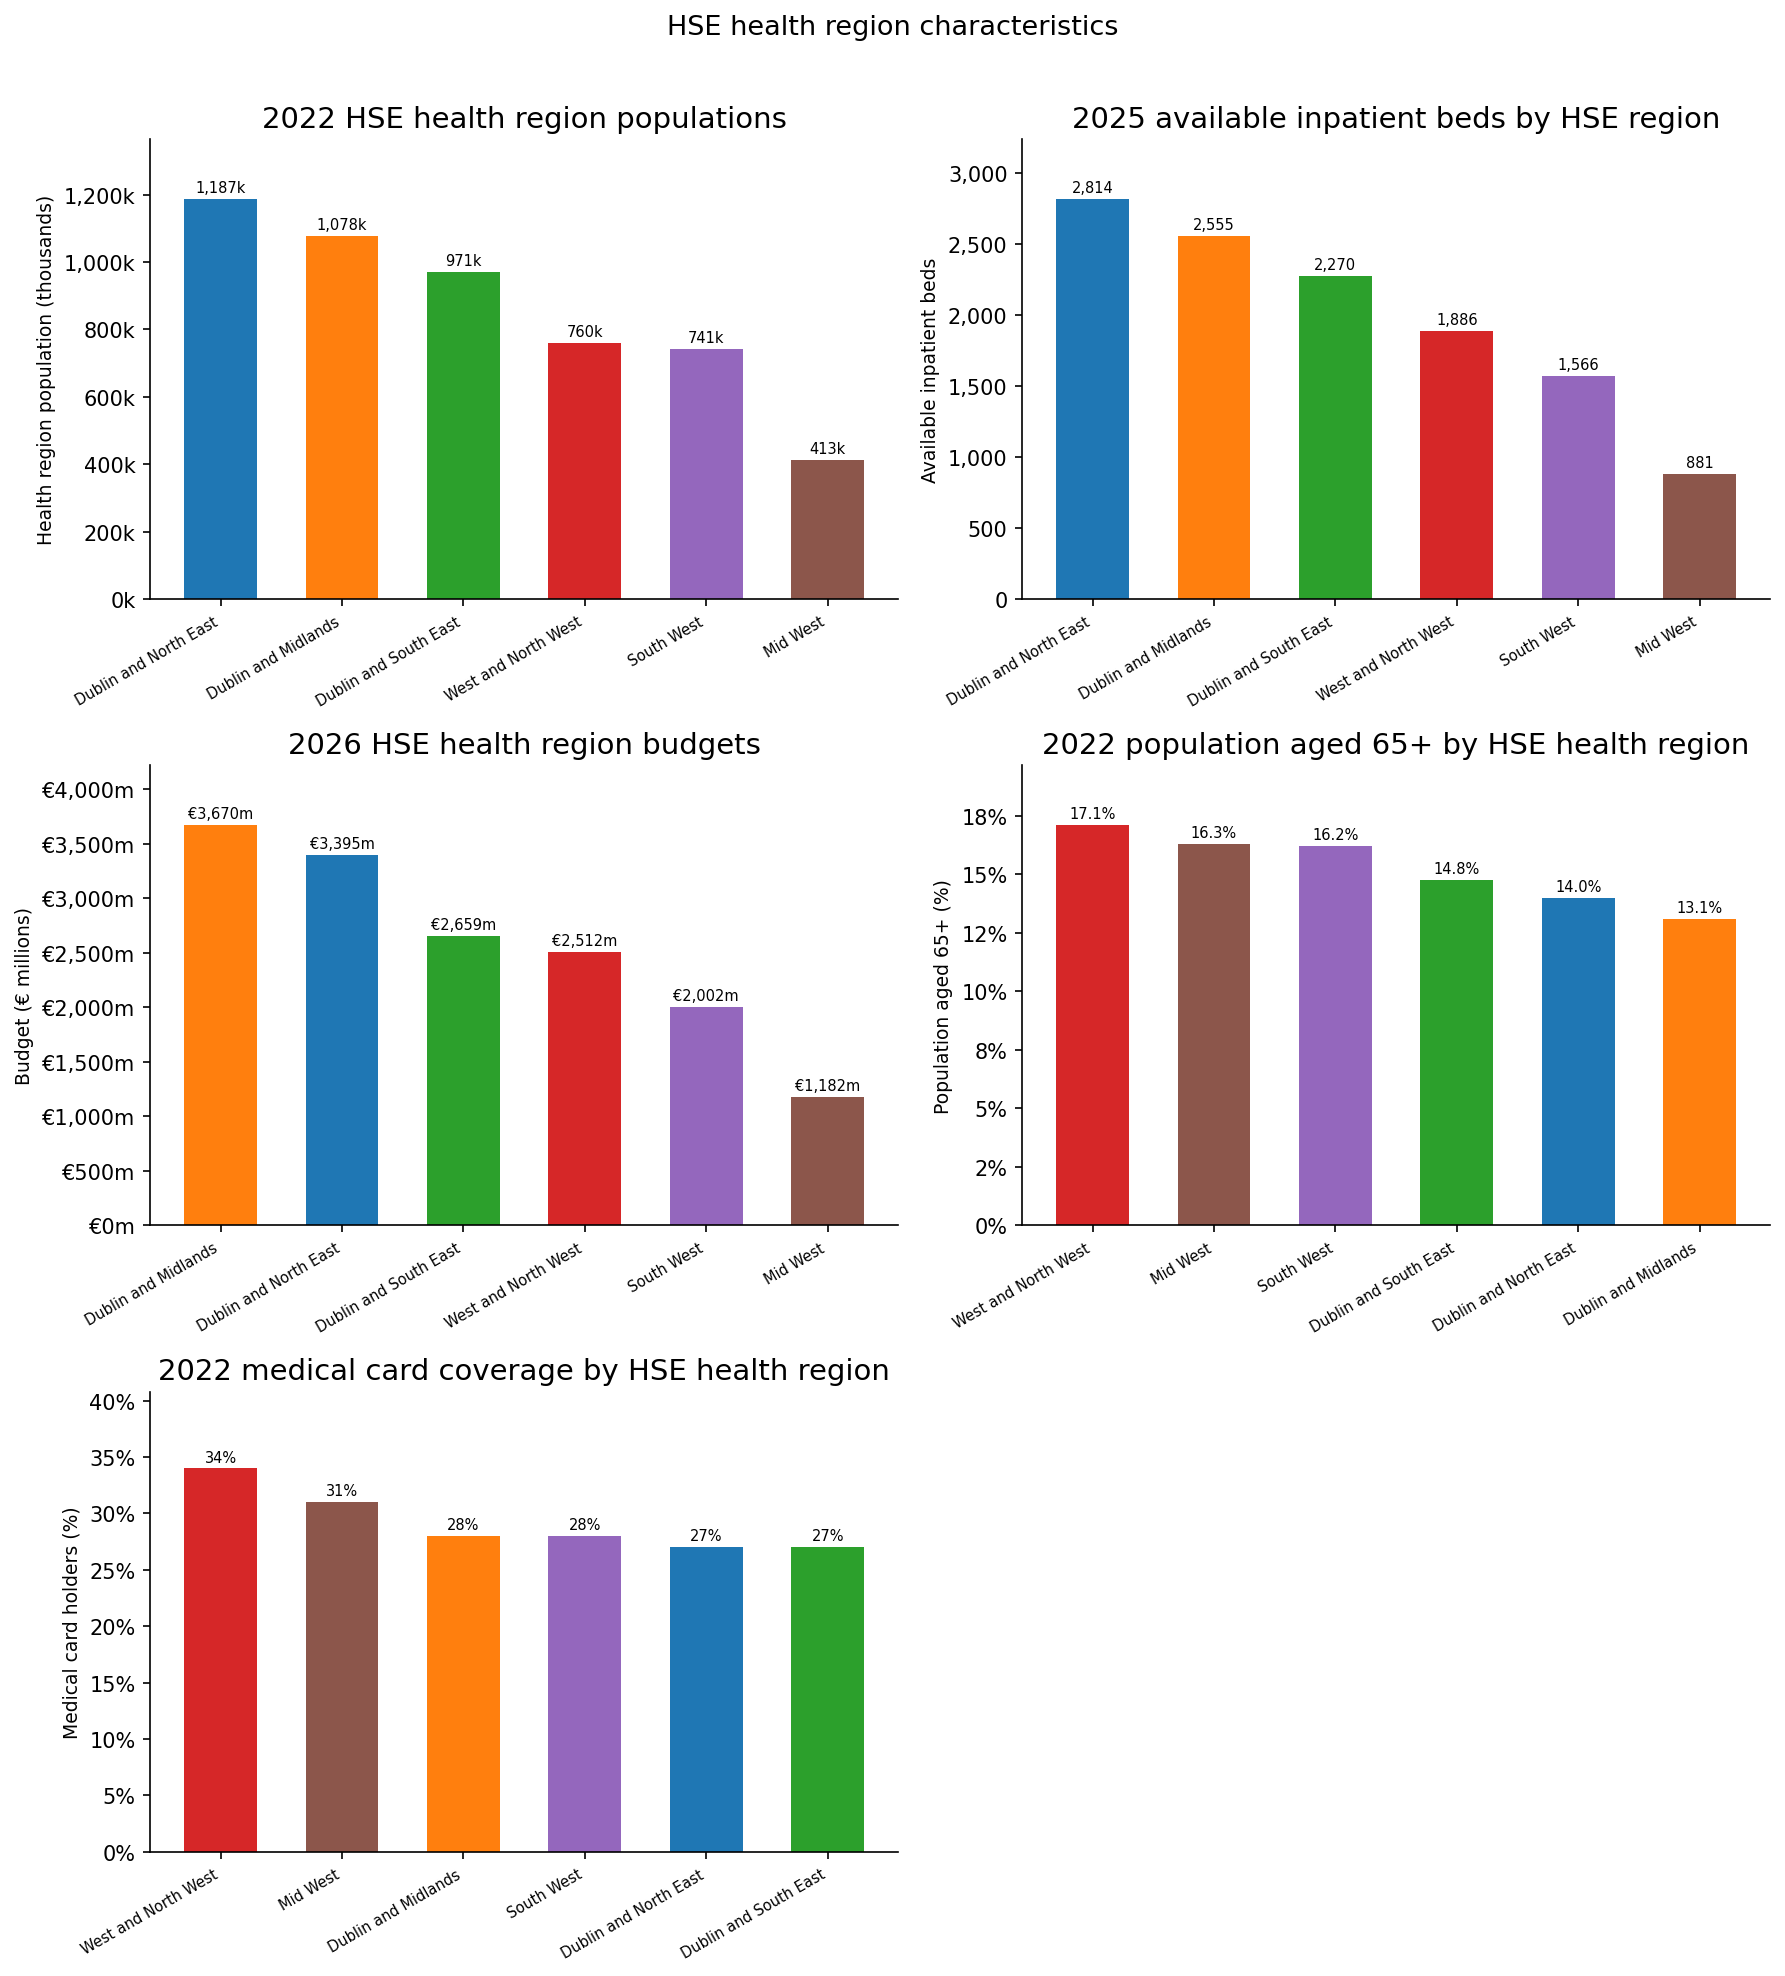

In [19]:
def _sort_desc(regions, values):
    pairs = sorted(zip(regions, values), key=lambda p: p[1], reverse=True)
    x = [p[0] for p in pairs]
    y = [p[1] for p in pairs]
    colors = [REGION_COLOR[r] for r in x]
    return x, y, colors

fig, axes = plt.subplots(3, 2, figsize=(12, 13), dpi=150)
axes = axes.flatten()

x, y, c = _sort_desc(catch["Region"].tolist(), catch["Population_k"].tolist())
_bar_with_labels(axes[0], x, y, fmt=lambda v: f"{v:,.0f}k",
    ylabel="Health region population (thousands)", title="2022 HSE health region populations", colors=c)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}k"))

x, y, c = _sort_desc(beds_by_region["region"].tolist(), beds_by_region["available_inpatient"].tolist())
_bar_with_labels(axes[1], x, y, fmt=lambda v: f"{int(v):,}",
    ylabel="Available inpatient beds", title="2025 available inpatient beds by HSE region", colors=c)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

x, y, c = _sort_desc(budget["Region"].tolist(), budget["Budget_m"].tolist())
_bar_with_labels(axes[2], x, y, fmt=lambda v: f"€{v:,.0f}m",
    ylabel="Budget (€ millions)", title="2026 HSE health region budgets", colors=c)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{int(x):,}m"))

x, y, c = _sort_desc(pct_60plus["HSE Regions"].tolist(), pct_60plus["Pct_60plus"].tolist())
_bar_with_labels(axes[3], x, y, fmt=lambda v: f"{v:.1f}%",
    ylabel="Population aged 65+ (%)", title="2022 population aged 65+ by HSE health region", colors=c)
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

x, y, c = _sort_desc(mc["Region"].tolist(), mc["Pct"].tolist())
_bar_with_labels(axes[4], x, y, fmt=lambda v: f"{v}%",
    ylabel="Medical card holders (%)", title="2022 medical card coverage by HSE health region",
    colors=c, ylim_factor=1.2)
axes[4].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}%"))

axes[5].set_visible(False)

plt.suptitle("HSE health region characteristics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Double encoded !

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

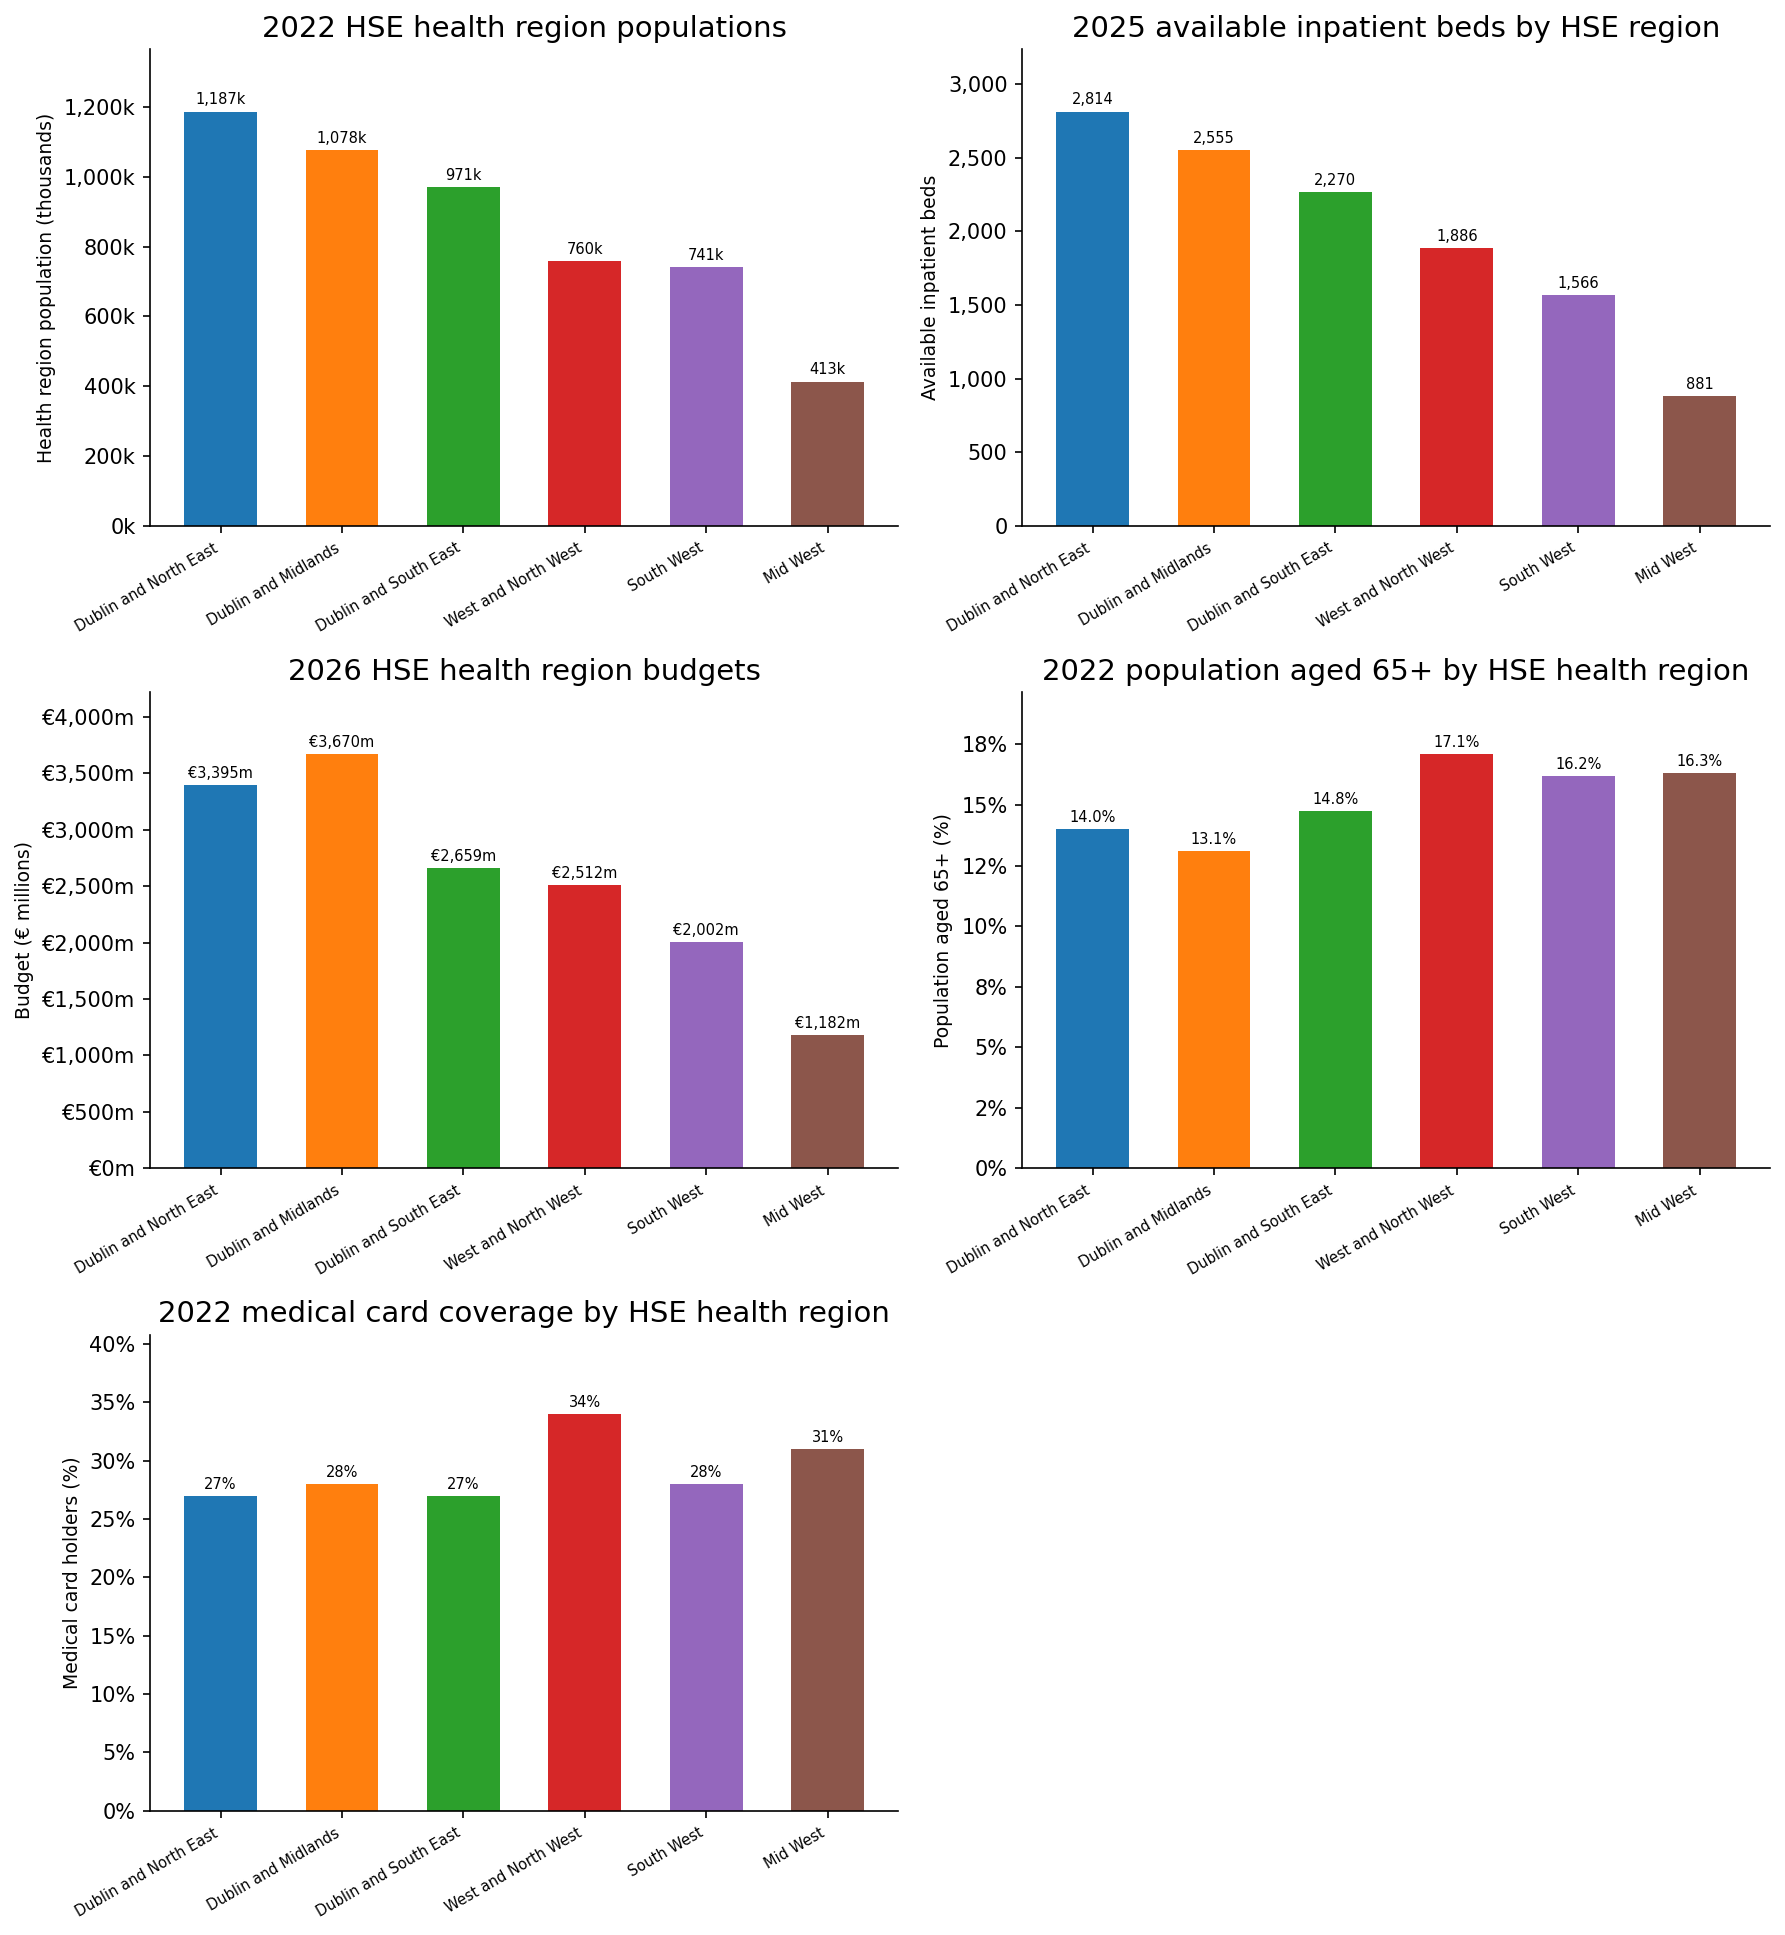

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13), dpi=150)
axes = axes.flatten()

bar_colors = [REGION_COLOR[r] for r in pop_order]

_bar_with_labels(axes[0], pop_order, pop_vals, fmt=lambda v: f"{v:,.0f}k",
    ylabel="Health region population (thousands)", title="2022 HSE health region populations", colors=bar_colors)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}k"))

_bar_with_labels(axes[1], pop_order, beds_vals, fmt=lambda v: f"{int(v):,}",
    ylabel="Available inpatient beds", title="2025 available inpatient beds by HSE region", colors=bar_colors)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

_bar_with_labels(axes[2], pop_order, budget_vals, fmt=lambda v: f"€{v:,.0f}m",
    ylabel="Budget (€ millions)", title="2026 HSE health region budgets", colors=bar_colors)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{int(x):,}m"))

_bar_with_labels(axes[3], pop_order, age_vals, fmt=lambda v: f"{v:.1f}%",
    ylabel="Population aged 65+ (%)", title="2022 population aged 65+ by HSE health region", colors=bar_colors)
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

_bar_with_labels(axes[4], pop_order, mc_vals, fmt=lambda v: f"{v}%",
    ylabel="Medical card holders (%)", title="2022 medical card coverage by HSE health region",
    colors=bar_colors, ylim_factor=1.2)
axes[4].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}%"))

axes[5].set_visible(False)

# plt.suptitle("HSE health region characteristics", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_4488/2147960712.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")


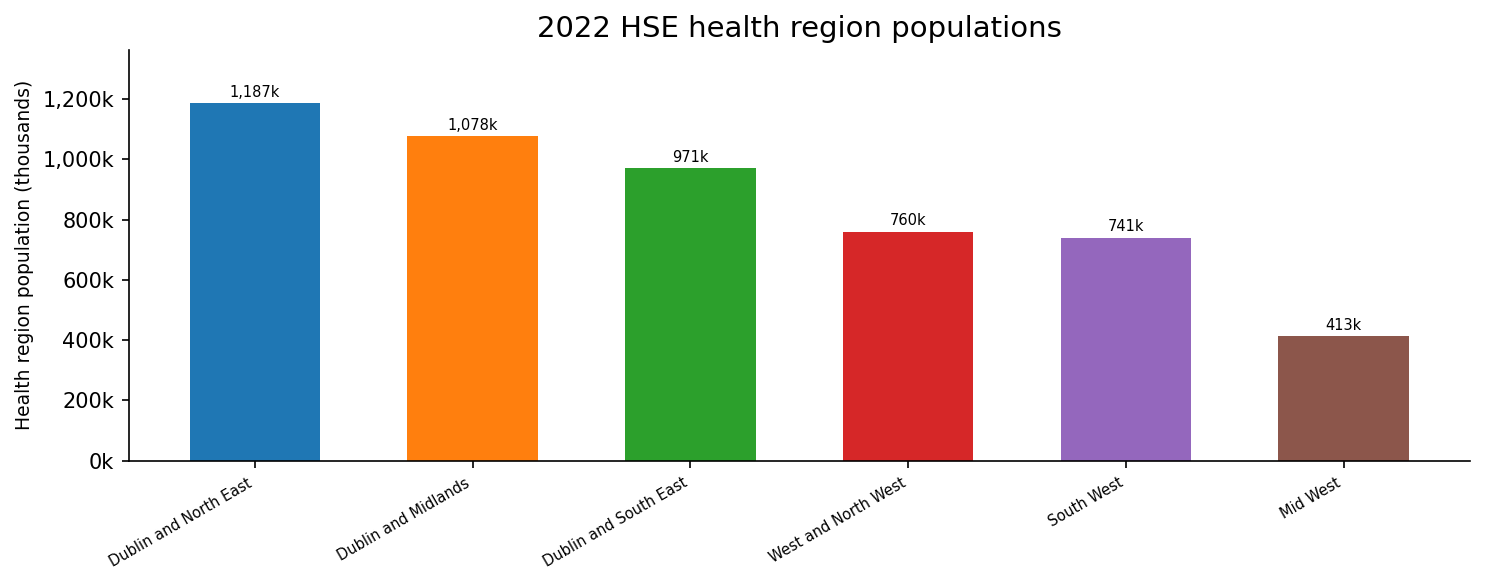

In [21]:
x, y, c = _sort_desc(catch["Region"].tolist(), catch["Population_k"].tolist())

fig, ax = plt.subplots(figsize=STD_BAR_FIG_SIZE, dpi=150)
_bar_with_labels(
    ax, x, y,
    fmt=lambda v: f"{v:,.0f}k",
    ylabel="Health region population (thousands)",
    title="2022 HSE health region populations",
    colors=c,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}k"))
plt.tight_layout()
plt.show()